# Una IA que nunca vio un hospital de Stanford lee sus tomografías mejor que la IA entrenada allí

5.125 tomografías de urgencias de Stanford. RADAR, un modelo que nunca vio un hospital de EE. UU., las clasifica con un AUC medio de 0,883 en 21 hallazgos. Merlin, el modelo entrenado con los datos de ese mismo hospital, llega a 0,812. ¿Cómo se gana fuera de casa?

:::{image} figuras/pixabot.png
:alt: Pixabot mascot
:width: 80px
:align: center
:figclass: pixabot-mascot
:::

**Paper:** Zhang et al. (2026). *An expert-level generalist AI for abdominal CT diagnosis*. **Science** 393(6817).
DOI: [10.1126/science.aec6129](https://doi.org/10.1126/science.aec6129) · Datos: Tablas S1–S9 del material suplementario + scores del modelo en [GitHub](https://github.com/alibaba-damo-academy/damo-radar)

[![Abrir en Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Ciencia-a-Mordiscos/lab/blob/main/papers/2026-09-18-radar-ia-generalista-tc-abdominal/notebook.ipynb)

**Video:** pendiente

## Qué hicieron

Un equipo de 37 autores construyó RADAR (*Rapid Abdominal Diagnosis with AI and Radiology*), un modelo de visión y lenguaje que aprendió a leer tomografías computarizadas (TC) abdominales con contraste directamente de los informes que escriben los radiólogos — sin anotación manual. Lo entrenaron con 424.911 exámenes y 15 millones de pares imagen-texto, uno por estructura anatómica.

Luego lo evaluaron en 146 hallazgos repartidos en 18 estructuras anatómicas: una cohorte interna de 39.160 exámenes, ocho hospitales externos, el test set público de Merlin (5.125 TC de urgencias de Stanford, EE. UU.) y un estudio con 26 radiólogos de 14 centros.

La métrica es el **AUC** (área bajo la curva ROC): mide cuán bien ordena el modelo los casos con y sin un hallazgo. 0,5 es azar, 1,0 es orden perfecto. Un AUC de 0,88 **no** significa "acierta el 88 %" — significa que separa bien positivos de negativos, y eso no es un diagnóstico.

**Lo que abrimos aquí:** las tablas S1, S2, S7, S8 y S9 del suplementario (AUC por hallazgo, positivos por cohorte, demografía de los lectores) y el CSV con los scores crudos que RADAR emitió sobre las 5.125 TC de Stanford, publicado en el repositorio de los autores. **Lo que no tenemos:** las etiquetas de Merlin (acuerdo de uso de datos de Stanford), así que los AUC en Stanford los leemos de la tabla del paper — no los recomputamos.

In [1]:
# ══════════════════════════════════════════════════════════════
# Configuración — modifica estos valores para explorar
# ══════════════════════════════════════════════════════════════
UMBRAL_POSITIVO = 0.5          # Umbral didáctico sobre los scores (NO es del paper; scores sin calibrar)
ZONA_GRIS = (0.3, 0.7)         # Rango de scores que llamamos "duda"
HALLAZGOS_ZOOM = ['abdominal_aortic_aneurysm', 'hepatomegaly', 'gallstones',
                  'aortic_valve_calcification', 'cardiomegaly', 'fracture']
FUENTE = 'Fuente: Zhang et al. (2026), Science | Datos: Tablas S1–S9 del suplementario + GitHub alibaba-damo-academy/damo-radar'
COLOR_DATOS = '#2563EB'        # RADAR
COLOR_ALERTA = '#DC2626'
COLOR_REFERENCIA = '#D97706'   # Merlin
COLOR_SECUNDARIO = '#059669'   # fVLM
COLOR_CONTEXTO = '#BBBBBB'     # CT-CLIP / baselines generalistas

import os, urllib.request
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
from scipy import stats

BASE = 'https://raw.githubusercontent.com/Ciencia-a-Mordiscos/lab/main/papers/2026-09-18-radar-ia-generalista-tc-abdominal'
ARCHIVOS = ['merlin_test_auc_por_modelo.csv', 'auc_interno_146_hallazgos.csv',
            'auc_externo_8_centros.csv', 'positivos_por_cohorte.csv',
            'lectores_reader_study.csv', 'radar_scores_merlin_test.csv']
os.makedirs('datos', exist_ok=True)
os.makedirs('figuras', exist_ok=True)
for a in ARCHIVOS:
    if not os.path.exists(f'datos/{a}'):
        urllib.request.urlretrieve(f'{BASE}/datos/{a}', f'datos/{a}')

# Estilo CaM (local → /tmp → GitHub)
style_file = '../../cam.mplstyle'
if not os.path.exists(style_file):
    style_file = '/tmp/cam.mplstyle'
    if not os.path.exists(style_file):
        urllib.request.urlretrieve('https://raw.githubusercontent.com/Ciencia-a-Mordiscos/lab/main/cam.mplstyle', style_file)
plt.style.use(style_file)

# Formato español: 1.234 y 0,88
def es(n, dec=0):
    s = f'{n:,.{dec}f}'
    return s.replace(',', 'X').replace('.', ',').replace('X', '.')
fmt_coma = FuncFormatter(lambda x, _: f'{x:.1f}'.replace('.', ','))

merlin = pd.read_csv('datos/merlin_test_auc_por_modelo.csv')      # Tabla S8
interno = pd.read_csv('datos/auc_interno_146_hallazgos.csv')     # Tabla S2
externo = pd.read_csv('datos/auc_externo_8_centros.csv')         # Tabla S7
positivos = pd.read_csv('datos/positivos_por_cohorte.csv')       # Tabla S1
lectores = pd.read_csv('datos/lectores_reader_study.csv')        # Tabla S9
scores = pd.read_csv('datos/radar_scores_merlin_test.csv')       # GitHub damo-radar

NOMBRES = {
    'renal hypodensities': 'Hipodensidades renales', 'renal cyst': 'Quiste renal',
    'abdominal aortic aneurysm': 'Aneurisma de aorta abdominal', 'hiatal hernia': 'Hernia de hiato',
    'cardiomegaly': 'Cardiomegalia', 'splenomegaly': 'Esplenomegalia',
    'pleural effusion': 'Derrame pleural', 'hepatic steatosis': 'Esteatosis hepática',
    'appendicitis': 'Apendicitis', 'gallstones': 'Litiasis vesicular',
    'pancreatic atrophy': 'Atrofia pancreática', 'bowel obstruction': 'Obstrucción intestinal',
    'atelectasis': 'Atelectasia', 'biliary ductal dilation': 'Dilatación de vía biliar',
    'hepatomegaly': 'Hepatomegalia', 'surgically absent gallbladder': 'Vesícula extirpada',
    'hydronephrosis': 'Hidronefrosis', 'submucosal edema': 'Edema submucoso',
    'atherosclerosis': 'Aterosclerosis', 'fracture': 'Fractura',
    'aortic valve calcification': 'Calcificación de válvula aórtica',
}
# Las columnas del CSV de scores usan guion bajo
NOMBRES_COL = {k.replace(' ', '_'): v for k, v in NOMBRES.items()}
COLS_SCORE = [c for c in scores.columns if c not in ('scan_id', 'gallbladder_segment_volume')]

in_scope = merlin[merlin.scope == 'in_scope'].copy()
print(f'Test set de Merlin (S8): {len(in_scope)} hallazgos evaluados + {(merlin.scope == "out_of_scope").sum()} fuera de alcance')
print(f'Cohorte interna (S2): {len(interno)} hallazgos en {interno.anatomy.nunique()} estructuras')
print(f'Centros externos (S7): {externo.filter(like="center_").notna().sum().sum()} celdas hallazgo×centro')
print(f'Scores crudos (GitHub): {es(len(scores))} TC × {len(COLS_SCORE)} hallazgos = {es(len(scores) * len(COLS_SCORE))} scores')
print(f'Lectores (S9): {len(lectores)} radiólogos')

Test set de Merlin (S8): 21 hallazgos evaluados + 9 fuera de alcance
Cohorte interna (S2): 146 hallazgos en 18 estructuras
Centros externos (S7): 818 celdas hallazgo×centro
Scores crudos (GitHub): 5.125 TC × 20 hallazgos = 102.500 scores
Lectores (S9): 26 radiólogos


## Aquí está.

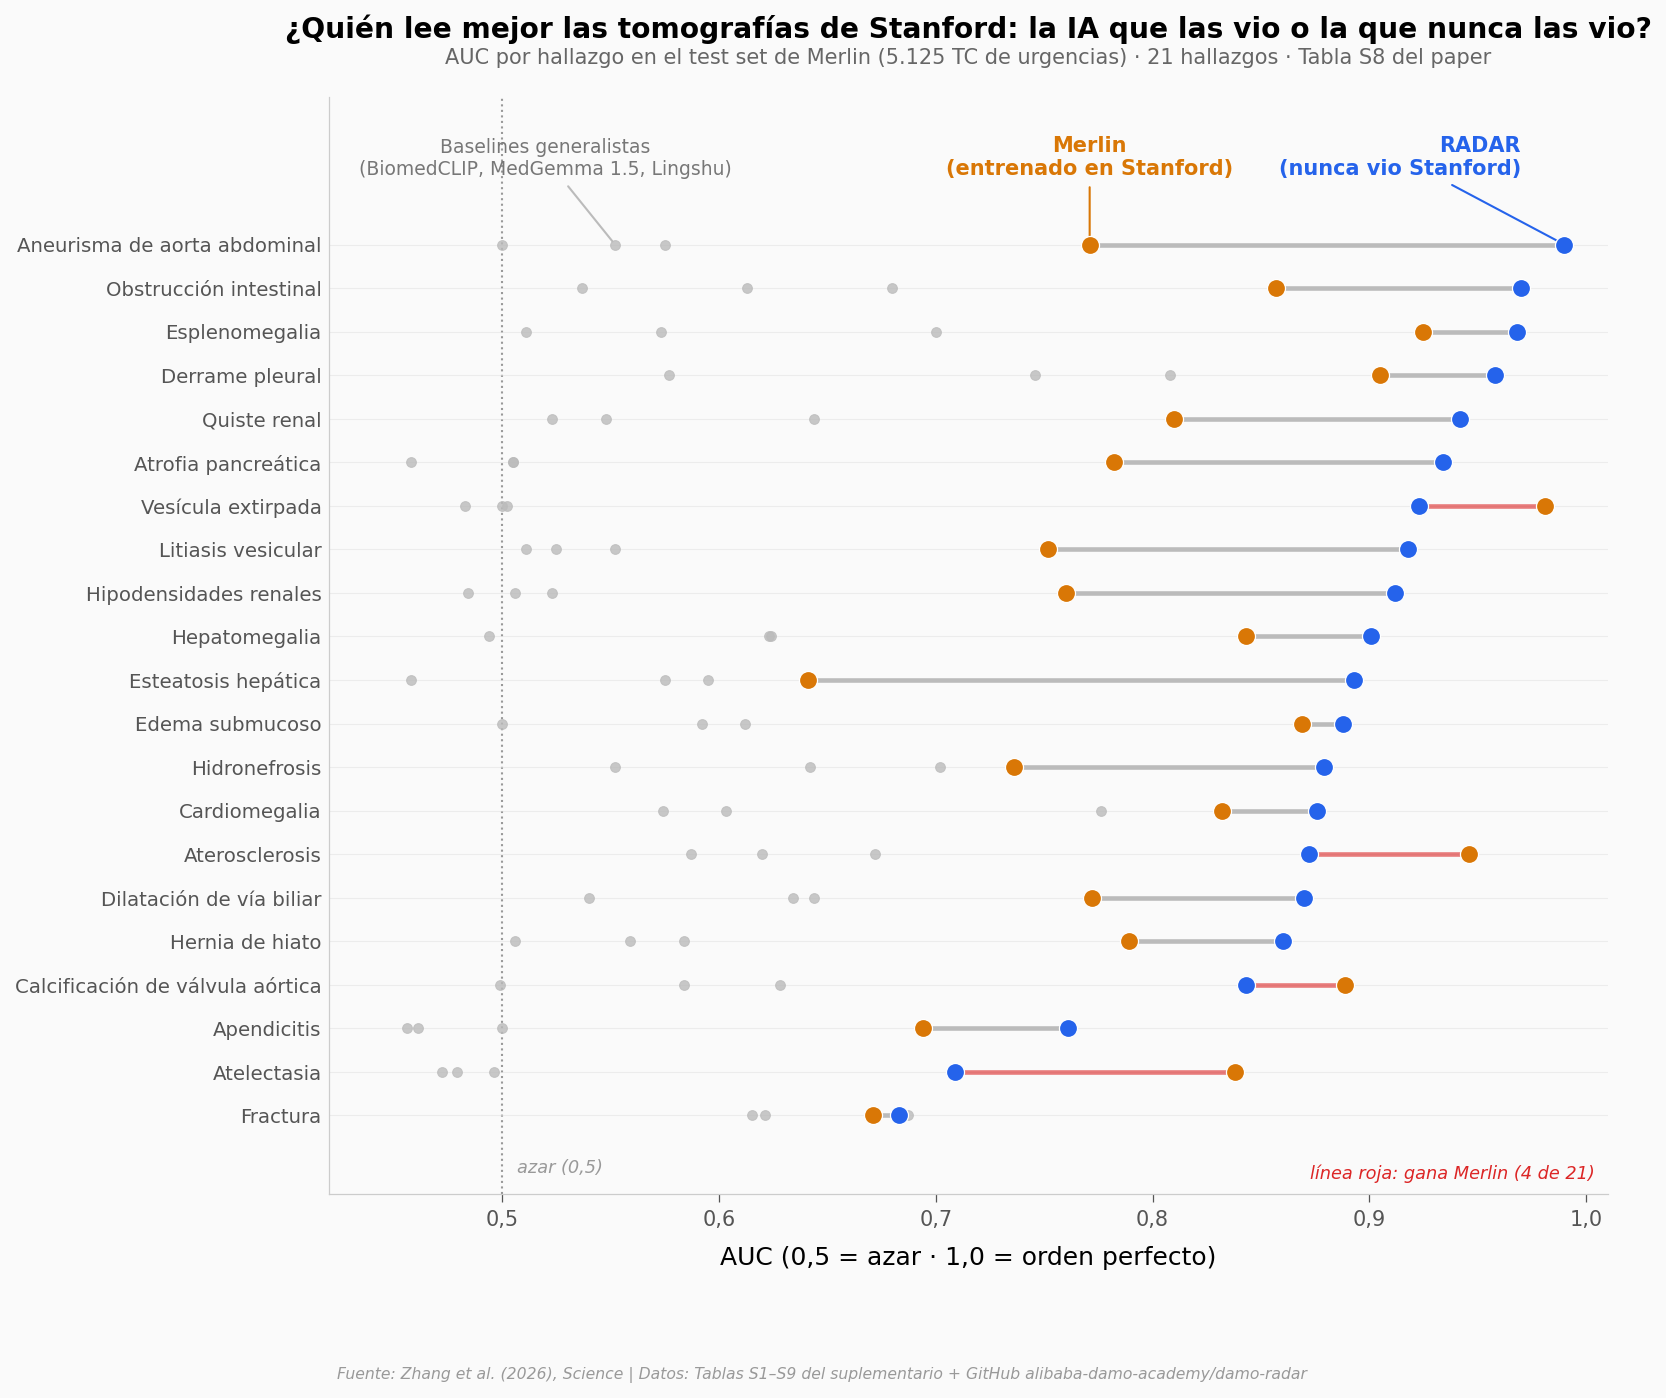

RADAR > Merlin en 17 de 21 hallazgos
Media RADAR 0.8833 · Merlin 0.8125 · RADAR+ (afinado) 0.9179
Mediana RADAR 0.893 (IQR 0.870–0.934) · Merlin 0.810 (IQR 0.760–0.869)
Diferencia pareada RADAR−Merlin: media +0.071, mediana +0.067, d pareado 0.73, Wilcoxon p = 0.0064 (n = 21)
Mayores ganancias: Esteatosis hepática +0.252, Aneurisma de aorta abdominal +0.219, Litiasis vesicular +0.166, Hipodensidades renales +0.152
Pierde en: Atelectasia (0.709 vs 0.838), Calcificación de válvula aórtica (0.843 vs 0.889), Aterosclerosis (0.872 vs 0.946), Vesícula extirpada (0.923 vs 0.981)
RADAR ≥ 0,9: 10/21 · < 0,8: Fractura 0.683, Atelectasia 0.709, Apendicitis 0.761
Baselines generalistas: medias [0.574, 0.555, 0.581] · celdas con AUC ≥ 0,8: 1 de 63
RADAR+ > RADAR en 18/21 · RADAR+ > Merlin en 19/21
Fuera de alcance (9): Merlin media 0.826 · RADAR+ 0.779


In [2]:
m = in_scope.sort_values('radar_auc').reset_index(drop=True)
m['nombre'] = m.finding.map(NOMBRES)
y = np.arange(len(m))

fig, ax = plt.subplots(figsize=(11, 9.5))
# Línea que une Merlin y RADAR: roja cuando gana Merlin
for i, row in m.iterrows():
    gana_merlin = row.merlin_auc > row.radar_auc
    ax.plot([row.merlin_auc, row.radar_auc], [i, i],
            color=COLOR_ALERTA if gana_merlin else COLOR_CONTEXTO,
            lw=2.2, alpha=0.6 if gana_merlin else 1, zorder=2)
# Baselines generalistas (sin entrenamiento médico específico en TC)
for col in ['biomedclip_auc', 'medgemma15_auc', 'lingshu_auc']:
    ax.scatter(m[col], y, color=COLOR_CONTEXTO, s=22, alpha=0.8, zorder=3)
ax.scatter(m.merlin_auc, y, color=COLOR_REFERENCIA, s=75, edgecolors='white', linewidths=0.6, zorder=5)
ax.scatter(m.radar_auc, y, color=COLOR_DATOS, s=75, edgecolors='white', linewidths=0.6, zorder=6)

ax.axvline(0.5, color='#999999', lw=1, ls=':', zorder=1)
ax.text(0.507, -1.2, 'azar (0,5)', fontsize=8.5, color='#999999', ha='left', va='center', style='italic')

# Inline labels sobre la fila superior (aneurisma: 0,50 / 0,77 / 0,99 bien separados)
top = m.iloc[-1]
i_top = len(m) - 1
ax.annotate('RADAR\n(nunca vio Stanford)', xy=(top.radar_auc, i_top), xytext=(top.radar_auc - 0.02, i_top + 1.6),
            fontsize=10, fontweight='bold', color=COLOR_DATOS, ha='right',
            arrowprops=dict(arrowstyle='-', color=COLOR_DATOS, lw=1))
ax.annotate('Merlin\n(entrenado en Stanford)', xy=(top.merlin_auc, i_top), xytext=(top.merlin_auc, i_top + 1.6),
            fontsize=10, fontweight='bold', color=COLOR_REFERENCIA, ha='center',
            arrowprops=dict(arrowstyle='-', color=COLOR_REFERENCIA, lw=1))
ax.annotate('Baselines generalistas\n(BiomedCLIP, MedGemma 1.5, Lingshu)', xy=(top.lingshu_auc, i_top),
            xytext=(0.52, i_top + 1.6), fontsize=9, color='#777777', ha='center',
            arrowprops=dict(arrowstyle='-', color=COLOR_CONTEXTO, lw=1))
ax.text(0.99, 0.01, 'línea roja: gana Merlin (4 de 21)', transform=ax.transAxes, fontsize=8.5,
        color=COLOR_ALERTA, style='italic', ha='right', va='bottom')

ax.set_yticks(y)
ax.set_yticklabels(m.nombre, fontsize=9.5)
ax.set_ylim(-1.8, len(m) + 2.4)
ax.set_xlim(0.42, 1.01)
ax.xaxis.set_major_formatter(fmt_coma)
ax.set_xlabel('AUC (0,5 = azar · 1,0 = orden perfecto)')
ax.set_title('¿Quién lee mejor las tomografías de Stanford: la IA que las vio o la que nunca las vio?',
             fontsize=13.5, fontweight='bold', pad=28)
ax.text(0.5, 1.03, 'AUC por hallazgo en el test set de Merlin (5.125 TC de urgencias) · 21 hallazgos · Tabla S8 del paper',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')
fig.text(0.13, -0.02, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/hero_radar_vs_merlin.png', dpi=200, bbox_inches='tight')
plt.show()

d = m.radar_auc - m.merlin_auc
w = stats.wilcoxon(m.radar_auc, m.merlin_auc)
print(f'RADAR > Merlin en {(d > 0).sum()} de {len(m)} hallazgos')
print(f'Media RADAR {m.radar_auc.mean():.4f} · Merlin {m.merlin_auc.mean():.4f} · RADAR+ (afinado) {m.radar_plus_auc.mean():.4f}')
print(f'Mediana RADAR {m.radar_auc.median():.3f} (IQR {m.radar_auc.quantile(.25):.3f}–{m.radar_auc.quantile(.75):.3f}) · '
      f'Merlin {m.merlin_auc.median():.3f} (IQR {m.merlin_auc.quantile(.25):.3f}–{m.merlin_auc.quantile(.75):.3f})')
print(f'Diferencia pareada RADAR−Merlin: media {d.mean():+.3f}, mediana {d.median():+.3f}, '
      f'd pareado {d.mean() / d.std(ddof=1):.2f}, Wilcoxon p = {w.pvalue:.4f} (n = {len(m)})')
print('Mayores ganancias:', ', '.join(f'{NOMBRES[r.finding]} {r.radar_auc - r.merlin_auc:+.3f}' for _, r in m.assign(g=d).nlargest(4, 'g').iterrows()))
print('Pierde en:', ', '.join(f'{NOMBRES[r.finding]} ({r.radar_auc:.3f} vs {r.merlin_auc:.3f})' for _, r in m[d < 0].iterrows()))
print(f'RADAR ≥ 0,9: {(m.radar_auc >= 0.9).sum()}/21 · < 0,8: ' + ', '.join(f'{NOMBRES[r.finding]} {r.radar_auc:.3f}' for _, r in m[m.radar_auc < 0.8].iterrows()))
base = m[['biomedclip_auc', 'medgemma15_auc', 'lingshu_auc']]
print(f'Baselines generalistas: medias {base.mean().round(3).tolist()} · celdas con AUC ≥ 0,8: {(base >= 0.8).sum().sum()} de {base.size}')
print(f'RADAR+ > RADAR en {(m.radar_plus_auc > m.radar_auc).sum()}/21 · RADAR+ > Merlin en {(m.radar_plus_auc > m.merlin_auc).sum()}/21')
fuera = merlin[merlin.scope == 'out_of_scope']
print(f'Fuera de alcance ({len(fuera)}): Merlin media {fuera.merlin_auc.mean():.3f} · RADAR+ {fuera.radar_plus_auc.mean():.3f}')

Lo primero que salta: casi todo el gráfico está a la derecha del punto naranja. RADAR supera a Merlin en 17 de los 21 hallazgos del test set de Merlin sin haber visto sus datos de entrenamiento. La mediana de RADAR es 0,893 (IQR 0,870–0,934); la de Merlin, 0,810 (IQR 0,760–0,869). Como son los mismos 21 hallazgos, la comparación es pareada: la diferencia media es +0,071 de AUC, un tamaño de efecto de d = 0,73 (medio), con Wilcoxon p = 0,006. Ojo: n = 21 es una muestra pequeña, y eso pesa más que la p.

Las ganancias grandes son en hallazgos de "textura de órgano": esteatosis hepática (+0,252, de 0,641 a 0,893), aneurisma de aorta abdominal (+0,219), litiasis vesicular (+0,166) e hipodensidades renales (+0,152). Merlin gana en cuatro: atelectasia (0,838 vs 0,709), aterosclerosis (0,946 vs 0,872), vesícula extirpada (0,981 vs 0,923) y calcificación de válvula aórtica (0,889 vs 0,843). Tres de esos cuatro son calcificaciones o ausencias, no lesiones dentro de un órgano.

Los puntos grises cuentan otra historia: los tres modelos generalistas (BiomedCLIP, MedGemma 1.5, Lingshu) rondan 0,55–0,58 de media, casi azar. En 63 celdas modelo×hallazgo, solo una pasa de 0,8. Un modelo "de todo" no lee TC abdominal; hace falta uno entrenado para eso.

Dos cosas que la gráfica no enseña. Primera: 3 de 21 hallazgos quedan por debajo de 0,8 — apendicitis (0,761), atelectasia (0,709) y fractura (0,683) — y en fractura RADAR ni siquiera supera a Lingshu (0,687). Segunda: hay 9 hallazgos más en el test set de Merlin (trombosis, metástasis, ascitis, aire libre…) donde RADAR no aplica porque no tienen una anatomía asociada o el modelo no la segmenta. Ahí, RADAR+ (la versión afinada con datos de Stanford) da 0,779 de media frente a 0,826 de Merlin — la ventaja se invierte. Y en los 21 hallazgos donde sí aplica, RADAR+ sube a 0,918 de media y supera a RADAR en 18 de 21.

Y la salvedad estructural: estos AUC vienen de la Tabla S8 del paper. Las etiquetas de Merlin están bajo acuerdo de uso de datos, así que no podemos recalcularlos; sí podemos comprobar que la media de la tabla (0,8833) coincide con el 0,883 del abstract.

## Eso fue fuera de casa. ¿Y en casa?

La cohorte interna tiene 39.160 exámenes y los 146 hallazgos completos. Aquí el paper compara RADAR con tres modelos de TC entrenados con supervisión: CT-CLIP, Merlin y fVLM. Un punto por hallazgo.

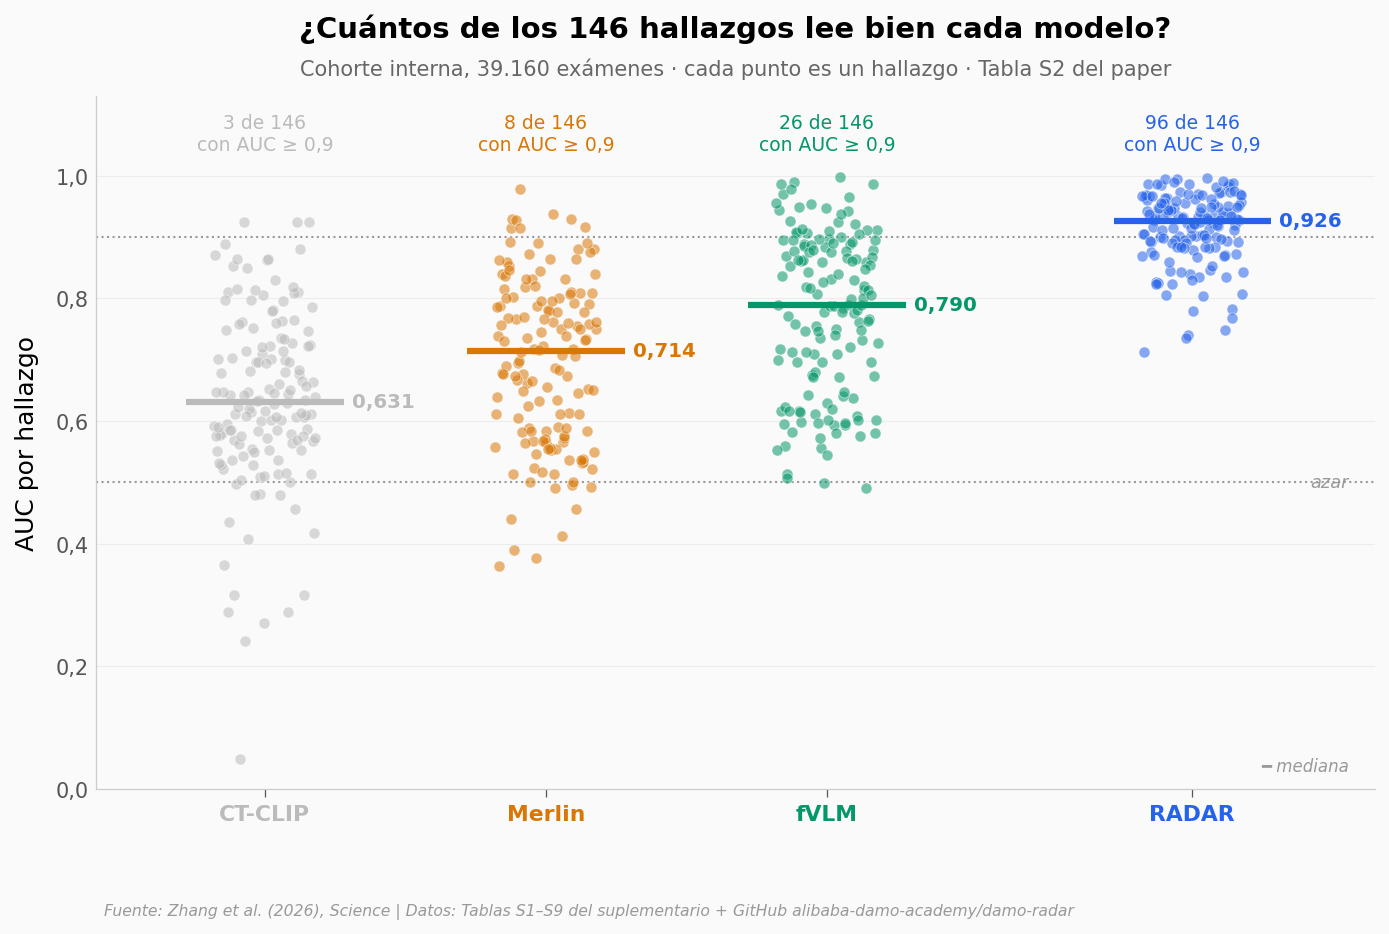

CT-CLIP  media 0.634 · mediana 0.631 · IQR 0.565–0.724 · ≥0,9:   3 · <0,8: 127
Merlin   media 0.697 · mediana 0.714 · IQR 0.582–0.801 · ≥0,9:   8 · <0,8: 108
fVLM     media 0.776 · mediana 0.790 · IQR 0.673–0.885 · ≥0,9:  26 · <0,8:  75
RADAR    media 0.913 · mediana 0.926 · IQR 0.884–0.956 · ≥0,9:  96 · <0,8:   7
Mejor modelo por hallazgo: {'radar_auc': 138, 'fvlm_auc': 8}
RADAR mayor que fVLM en 138/146 · que Merlin 144/146 · que CT-CLIP 144/146
Brecha media RADAR−fVLM +0.137 · RADAR−Merlin +0.216 · RADAR−CT-CLIP +0.278
Significancia vs fVLM según el paper: {'***': 113, 'ns': 18, '**': 9, '*': 6}
Peores 3 de RADAR: Kidney / Nonenhancing cystic lesion 0.713, Large bowel / Appendicolith 0.735, Small bowel / Enteritis 0.740


In [3]:
modelos = [('CT-CLIP', 'ctclip_auc', COLOR_CONTEXTO), ('Merlin', 'merlin_auc', COLOR_REFERENCIA),
           ('fVLM', 'fvlm_auc', COLOR_SECUNDARIO), ('RADAR', 'radar_auc', COLOR_DATOS)]
positions = [0, 1, 2, 3.3]
np.random.seed(42)

fig, ax = plt.subplots(figsize=(11, 6))
for pos, (nombre, col, color) in zip(positions, modelos):
    vals = interno[col].values
    x_strip = np.linspace(pos - 0.18, pos + 0.18, len(vals))
    np.random.shuffle(x_strip)
    ax.scatter(x_strip, vals, color=color, s=28, alpha=0.55, edgecolors='white', linewidths=0.4, zorder=4)
    med = np.median(vals)
    ax.hlines(med, pos - 0.28, pos + 0.28, color=color, lw=3, zorder=5)
    ax.text(pos + 0.31, med, f'{med:.3f}'.replace('.', ','), fontsize=9.5, fontweight='bold', color=color, va='center')
    n9 = (vals >= 0.9).sum()
    ax.text(pos, 1.035, f'{n9} de 146\ncon AUC ≥ 0,9', fontsize=9, color=color, ha='center', va='bottom')

ax.axhline(0.9, color='#999999', lw=1, ls=':', zorder=1)
ax.axhline(0.5, color='#999999', lw=1, ls=':', zorder=1)
ax.text(3.72, 0.5, 'azar', fontsize=8.5, color='#999999', va='center', style='italic')
ax.set_xticks(positions)
ax.set_xticklabels([mname for mname, _, _ in modelos], fontsize=10.5, fontweight='bold')
for tick, (_, _, color) in zip(ax.get_xticklabels(), modelos):
    tick.set_color(color)
ax.set_xlim(-0.6, 3.95)
ax.set_ylim(0, 1.13)
ax.yaxis.set_major_formatter(fmt_coma)
ax.set_ylabel('AUC por hallazgo')
ax.set_title('¿Cuántos de los 146 hallazgos lee bien cada modelo?', fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, 'Cohorte interna, 39.160 exámenes · cada punto es un hallazgo · Tabla S2 del paper',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')
ax.text(0.98, 0.02, '━ mediana', transform=ax.transAxes, fontsize=8, color='#999999', ha='right', va='bottom', style='italic')
fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/interno_146_por_modelo.png', dpi=200, bbox_inches='tight')
plt.show()

for nombre, col, _ in modelos:
    v = interno[col]
    print(f'{nombre:8s} media {v.mean():.3f} · mediana {v.median():.3f} · IQR {v.quantile(.25):.3f}–{v.quantile(.75):.3f} · ≥0,9: {(v >= 0.9).sum():3d} · <0,8: {(v < 0.8).sum():3d}')
mejor = interno[['ctclip_auc', 'merlin_auc', 'fvlm_auc', 'radar_auc']].idxmax(axis=1).value_counts()
print('Mejor modelo por hallazgo:', {k: int(v) for k, v in mejor.items()})
print(f'RADAR mayor que fVLM en {(interno.radar_auc > interno.fvlm_auc).sum()}/146 · que Merlin {(interno.radar_auc > interno.merlin_auc).sum()}/146 · que CT-CLIP {(interno.radar_auc > interno.ctclip_auc).sum()}/146')
print(f'Brecha media RADAR−fVLM {(interno.radar_auc - interno.fvlm_auc).mean():+.3f} · RADAR−Merlin {(interno.radar_auc - interno.merlin_auc).mean():+.3f} · RADAR−CT-CLIP {(interno.radar_auc - interno.ctclip_auc).mean():+.3f}')
print('Significancia vs fVLM según el paper:', {k: int(v) for k, v in interno.fvlm_sig.fillna('ns').value_counts().items()})
peor = interno.nsmallest(3, 'radar_auc')
print('Peores 3 de RADAR:', ', '.join(f'{r.anatomy} / {r.finding} {r.radar_auc:.3f}' for _, r in peor.iterrows()))

## ¿Y en ocho hospitales que nunca vio?

La cohorte interna comparte escáneres, protocolos y estilo de informe con el entrenamiento. La prueba dura son los ocho centros externos de la Tabla S7: cada uno evaluó solo los hallazgos con casos suficientes (de 68 a 136 por centro), y solo 46 hallazgos aparecen en los ocho.

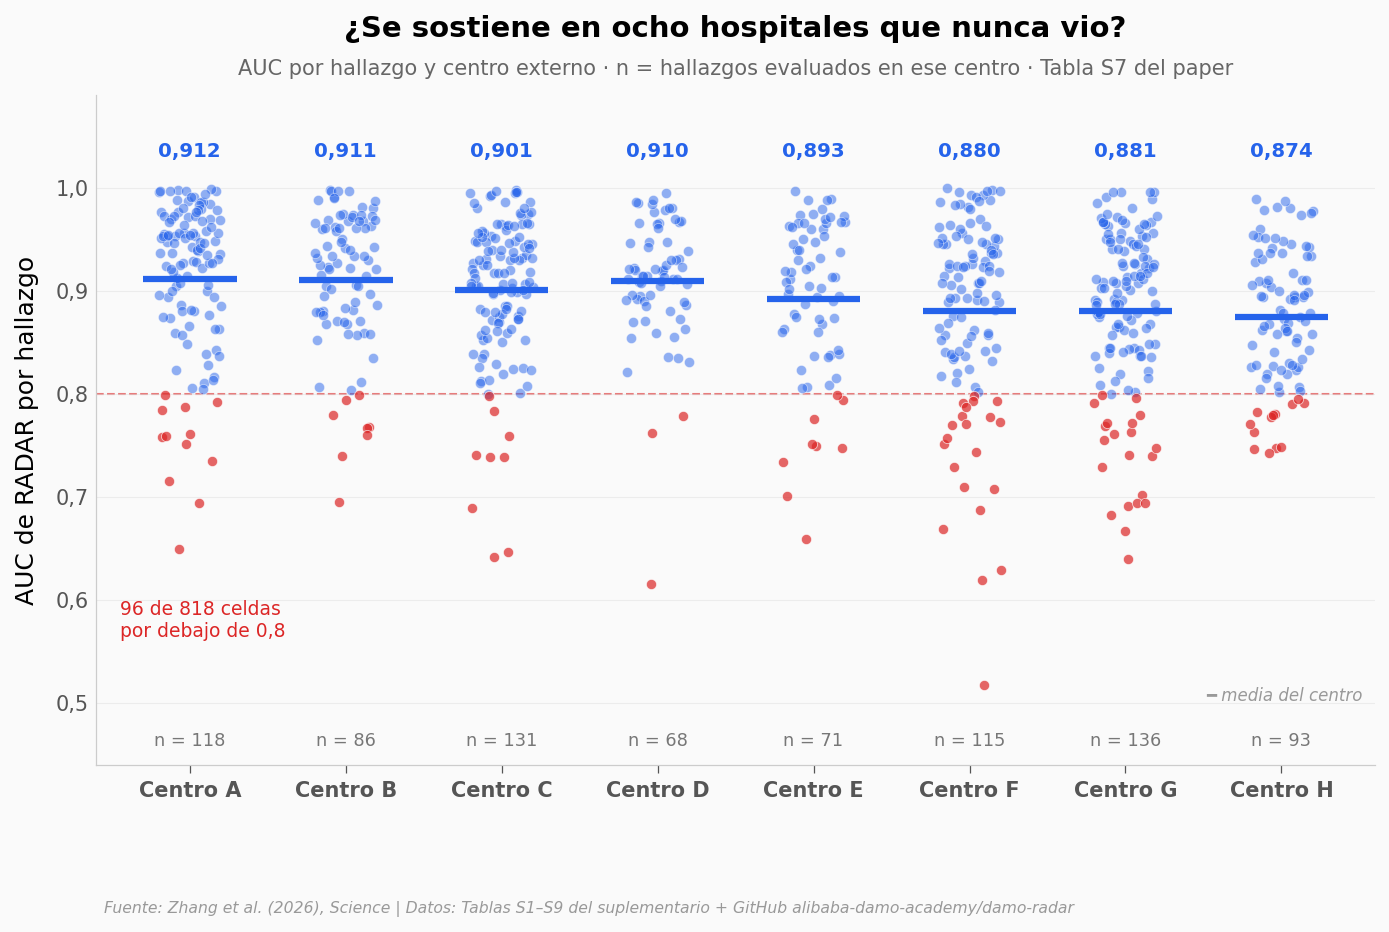

Media por centro: {'A': 0.912, 'B': 0.911, 'C': 0.901, 'D': 0.91, 'E': 0.893, 'F': 0.88, 'G': 0.881, 'H': 0.874}
Rango de medias por centro: 0.874–0.912
818 celdas · mediana 0.909 · IQR 0.854–0.952 · < 0,8: 96 (11.7 %)
Hallazgos evaluados en los 8 centros: 46
Desviación estándar entre centros por hallazgo: mediana 0.043 · máx 0.161


In [4]:
centros = [c for c in externo.columns if c.startswith('center_')]
letras = [c.split('_')[1].upper() for c in centros]
np.random.seed(42)

fig, ax = plt.subplots(figsize=(11, 5.8))
for i, (col, letra) in enumerate(zip(centros, letras)):
    vals = externo[col].dropna().values
    x_strip = np.linspace(i - 0.2, i + 0.2, len(vals))
    np.random.shuffle(x_strip)
    bajo = vals < 0.8
    ax.scatter(x_strip[~bajo], vals[~bajo], color=COLOR_DATOS, s=24, alpha=0.5, edgecolors='white', linewidths=0.4, zorder=4)
    ax.scatter(x_strip[bajo], vals[bajo], color=COLOR_ALERTA, s=24, alpha=0.7, edgecolors='white', linewidths=0.4, zorder=4)
    macro = vals.mean()
    ax.hlines(macro, i - 0.3, i + 0.3, color=COLOR_DATOS, lw=3, zorder=5)
    ax.text(i, 1.03, f'{macro:.3f}'.replace('.', ','), fontsize=9.5, fontweight='bold', color=COLOR_DATOS, ha='center')
    ax.text(i, 0.455, f'n = {len(vals)}', fontsize=8.5, color='#777777', ha='center', va='bottom')

ax.axhline(0.8, color=COLOR_ALERTA, lw=1, ls='--', alpha=0.6, zorder=1)
todas = externo[centros].stack().dropna()
ax.text(-0.45, 0.6, f'{(todas < 0.8).sum()} de {len(todas)} celdas\npor debajo de 0,8', fontsize=9, color=COLOR_ALERTA, va='top', ha='left')
ax.set_xticks(range(8))
ax.set_xticklabels([f'Centro {l}' for l in letras], fontsize=10, fontweight='bold')
ax.set_ylim(0.44, 1.09)
ax.set_xlim(-0.6, 7.6)
ax.yaxis.set_major_formatter(fmt_coma)
ax.set_ylabel('AUC de RADAR por hallazgo')
ax.set_title('¿Se sostiene en ocho hospitales que nunca vio?', fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, 'AUC por hallazgo y centro externo · n = hallazgos evaluados en ese centro · Tabla S7 del paper',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')
ax.text(0.99, 0.09, '━ media del centro', transform=ax.transAxes, fontsize=8, color='#999999', ha='right', va='bottom', style='italic')
fig.text(0.13, -0.06, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/externo_8_centros.png', dpi=200, bbox_inches='tight')
plt.show()

macros = externo[centros].mean()
print('Media por centro:', {l: round(v, 3) for l, v in zip(letras, macros)})
print(f'Rango de medias por centro: {macros.min():.3f}–{macros.max():.3f}')
print(f'{len(todas)} celdas · mediana {todas.median():.3f} · IQR {todas.quantile(.25):.3f}–{todas.quantile(.75):.3f} · < 0,8: {(todas < 0.8).sum()} ({100 * (todas < 0.8).mean():.1f} %)')
print(f'Hallazgos evaluados en los 8 centros: {externo[centros].notna().all(axis=1).sum()}')
sd = externo[centros].std(axis=1, ddof=1)
print(f'Desviación estándar entre centros por hallazgo: mediana {sd.median():.3f} · máx {sd.max():.3f}')

## Hasta aquí, tablas del paper. Ahora abramos lo único que podemos tocar

El repositorio de los autores publica los scores crudos que RADAR emitió sobre las 5.125 TC de Stanford: un número entre 0 y 1 por tomografía y por hallazgo, 102.500 en total. Sin las etiquetas no podemos saber cuáles acertó, pero sí podemos ver *cómo* responde: ¿es tajante o duda?

Estos scores no están calibrados como probabilidades, así que el umbral de 0,5 y la "zona gris" de 0,3 a 0,7 son nuestros, no del paper.

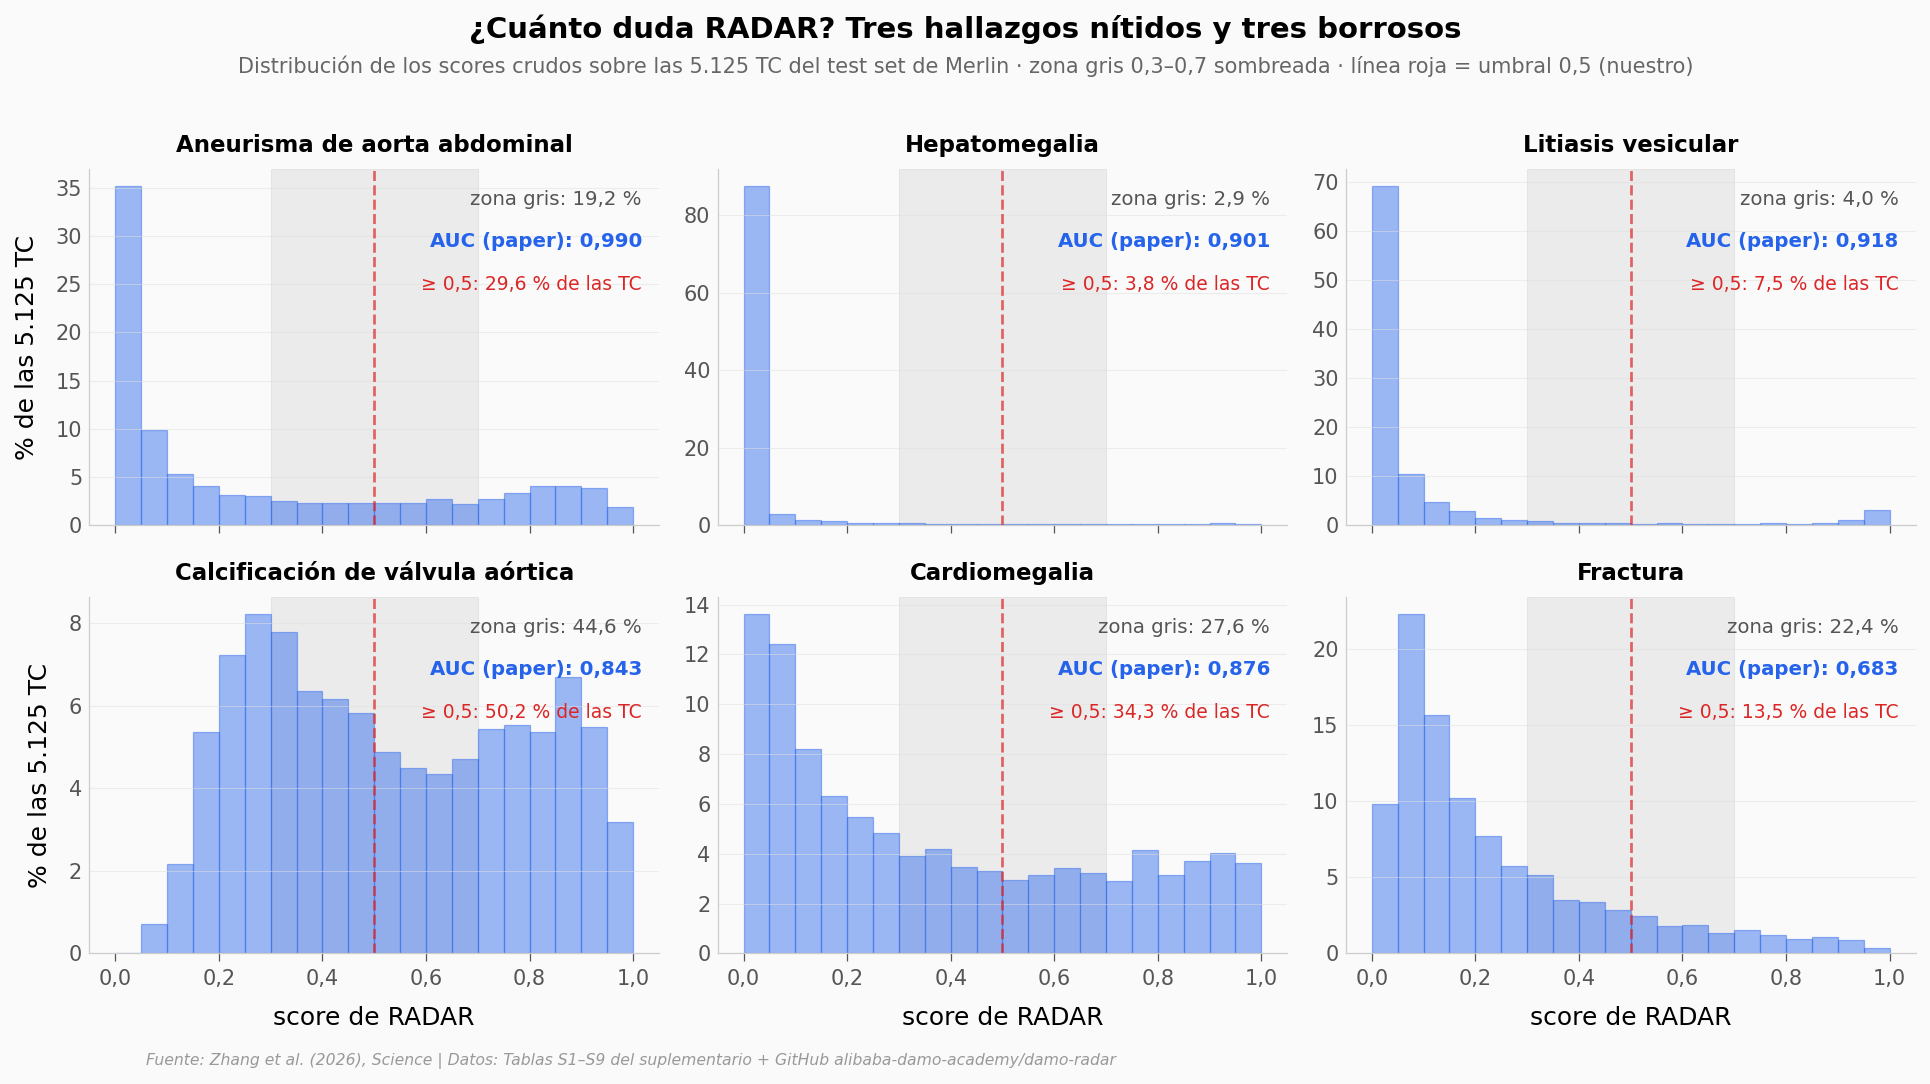

102.500 scores: 55.1 % por debajo de 0,1 · 6.4 % por encima de 0,9 · 14.7 % en zona gris
Zona gris por hallazgo — más dudoso: Calcificación de válvula aórtica 44.6 % · más nítido: Hepatomegalia 2.9 %
Marcados ≥ 0,5 — más frecuente: Calcificación de válvula aórtica 50.2 % · menos: Dilatación de vía biliar 3.6 %


In [5]:
auc_s8 = in_scope.set_index(in_scope.finding.str.replace(' ', '_')).radar_auc
lo, hi = ZONA_GRIS

fig, axes = plt.subplots(2, 3, figsize=(13, 7), sharex=True)
for ax, col in zip(axes.flat, HALLAZGOS_ZOOM):
    v = scores[col].dropna()
    gris = ((v >= lo) & (v <= hi)).mean()
    ax.hist(v, bins=20, range=(0, 1), weights=100 * np.ones(len(v)) / len(v),
            color=COLOR_DATOS, alpha=0.45, edgecolor=COLOR_DATOS, linewidth=0.6)
    ax.axvspan(lo, hi, color='#999999', alpha=0.15, zorder=0)
    ax.axvline(UMBRAL_POSITIVO, color=COLOR_ALERTA, lw=1.3, ls='--', alpha=0.7)
    ax.set_title(NOMBRES_COL[col], fontsize=11, fontweight='bold', pad=8)
    ax.text(0.97, 0.9, f'zona gris: {100 * gris:.1f} %'.replace('.', ','), transform=ax.transAxes,
            fontsize=9.5, color='#555555', ha='right')
    ax.text(0.97, 0.78, f'AUC (paper): {auc_s8[col]:.3f}'.replace('.', ','), transform=ax.transAxes,
            fontsize=9.5, color=COLOR_DATOS, fontweight='bold', ha='right')
    ax.text(0.97, 0.66, f'≥ 0,5: {100 * (v >= UMBRAL_POSITIVO).mean():.1f} % de las TC'.replace('.', ','),
            transform=ax.transAxes, fontsize=9, color=COLOR_ALERTA, ha='right')
    ax.xaxis.set_major_formatter(fmt_coma)
for ax in axes[1]:
    ax.set_xlabel('score de RADAR')
for ax in axes[:, 0]:
    ax.set_ylabel('% de las 5.125 TC')
plt.tight_layout(rect=[0, 0, 1, 0.9])
fig.suptitle('¿Cuánto duda RADAR? Tres hallazgos nítidos y tres borrosos', fontsize=14, fontweight='bold', y=0.99)
fig.text(0.5, 0.935, 'Distribución de los scores crudos sobre las 5.125 TC del test set de Merlin · zona gris 0,3–0,7 sombreada · línea roja = umbral 0,5 (nuestro)',
         fontsize=10, color='#666666', ha='center')
fig.text(0.08, -0.01, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/scores_zona_gris.png', dpi=200, bbox_inches='tight')
plt.show()

todos = scores[COLS_SCORE].stack()
print(f'{es(len(todos))} scores: {100 * (todos < 0.1).mean():.1f} % por debajo de 0,1 · {100 * (todos > 0.9).mean():.1f} % por encima de 0,9 · {100 * ((todos >= lo) & (todos <= hi)).mean():.1f} % en zona gris')
gris_h = scores[COLS_SCORE].apply(lambda s: ((s.dropna() >= lo) & (s.dropna() <= hi)).mean()).sort_values(ascending=False)
print('Zona gris por hallazgo — más dudoso:', f'{NOMBRES_COL[gris_h.index[0]]} {100 * gris_h.iloc[0]:.1f} %', '· más nítido:', f'{NOMBRES_COL[gris_h.index[-1]]} {100 * gris_h.iloc[-1]:.1f} %')
pos_h = scores[COLS_SCORE].apply(lambda s: (s.dropna() >= UMBRAL_POSITIVO).mean()).sort_values(ascending=False)
print('Marcados ≥ 0,5 — más frecuente:', f'{NOMBRES_COL[pos_h.index[0]]} {100 * pos_h.iloc[0]:.1f} %', '· menos:', f'{NOMBRES_COL[pos_h.index[-1]]} {100 * pos_h.iloc[-1]:.1f} %')

Aneurisma de aorta abdominal es el caso limpio: la distribución tiene forma de U — un 60,8 % de los scores por debajo de 0,3, un 20,0 % por encima de 0,7 y apenas un 19,2 % en la zona gris — y el AUC del paper es 0,990. Hepatomegalia es aún más tajante (2,9 % en zona gris). En el otro extremo, calcificación de válvula aórtica: el 44,6 % de las tomografías recibe un score entre 0,3 y 0,7, y la mitad (50,2 %) supera el umbral. El modelo no sabe bien qué decir — y su AUC allí (0,843) es de los más bajos. Fractura combina las dos cosas: 22,4 % de zona gris y el peor AUC de los 21 (0,683).

¿Más duda, menos AUC? Tentador, pero con 20 hallazgos la correlación de rangos no es significativa (ρ = −0,36, p = 0,12). No lo afirmamos.

En conjunto, de los 102.500 scores el 55,1 % está por debajo de 0,1 y solo el 6,4 % pasa de 0,9: RADAR es mayoritariamente un modelo que dice "no". El 14,7 % restante en zona gris es donde un radiólogo tendría que mirar dos veces.

Última pregunta: si aplicamos el umbral, ¿cuántas cosas marca RADAR en una tomografía cualquiera?

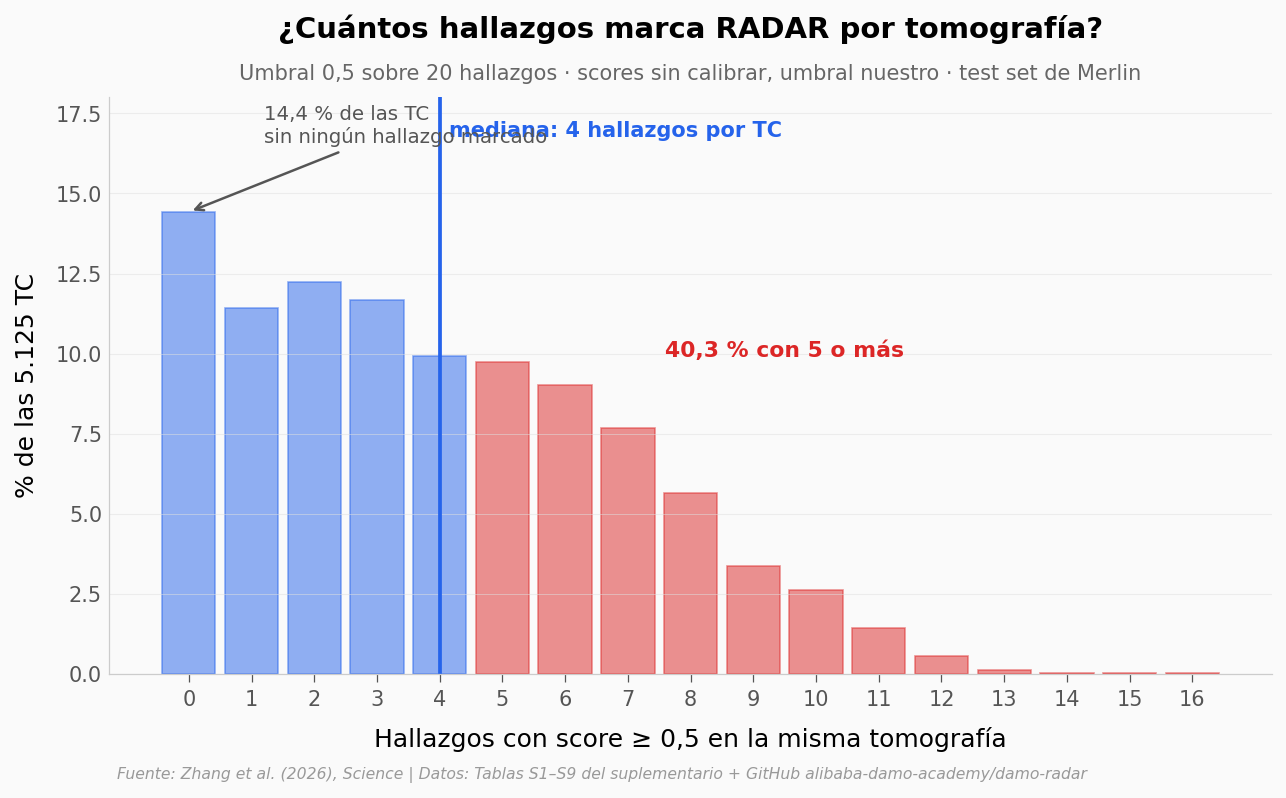

Hallazgos marcados por TC: media 3.95 · mediana 4 · IQR 1–6 · máx 16
TC con 0 hallazgos: 14.4 % · con ≥ 5: 40.3 %


In [6]:
marcados = (scores[COLS_SCORE] >= UMBRAL_POSITIVO).sum(axis=1)
mediana = marcados.median()
media = marcados.mean()

fig, ax = plt.subplots(figsize=(10, 5))
conteo = marcados.value_counts().sort_index()
pct = 100 * conteo / len(marcados)
colores = [COLOR_ALERTA if k >= 5 else COLOR_DATOS for k in conteo.index]
ax.bar(conteo.index, pct, color=colores, alpha=0.5, edgecolor=colores, linewidth=0.8, width=0.85)
y_max = pct.max() * 1.25
ax.set_ylim(0, y_max)
ax.axvline(mediana, color=COLOR_DATOS, lw=1.8)
ax.text(mediana + 0.15, y_max * 0.93, f'mediana: {mediana:.0f} hallazgos por TC', fontsize=10, fontweight='bold', color=COLOR_DATOS)
ax.annotate(f'{pct.loc[0]:.1f} % de las TC\nsin ningún hallazgo marcado'.replace('.', ','),
            xy=(0, pct.loc[0]), xytext=(1.2, pct.loc[0] + y_max * 0.12), fontsize=9.5, color='#555555',
            arrowprops=dict(arrowstyle='->', color='#555555', lw=1.2))
ax.text(9.5, y_max * 0.55, f'{pct[pct.index >= 5].sum():.1f} % con 5 o más'.replace('.', ','),
        fontsize=10.5, fontweight='bold', color=COLOR_ALERTA, ha='center')
ax.set_xticks(range(0, int(marcados.max()) + 1))
ax.set_xlabel('Hallazgos con score ≥ 0,5 en la misma tomografía')
ax.set_ylabel('% de las 5.125 TC')
ax.set_title('¿Cuántos hallazgos marca RADAR por tomografía?', fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, 'Umbral 0,5 sobre 20 hallazgos · scores sin calibrar, umbral nuestro · test set de Merlin',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')
fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/hallazgos_por_tc.png', dpi=200, bbox_inches='tight')
plt.show()

print(f'Hallazgos marcados por TC: media {media:.2f} · mediana {mediana:.0f} · IQR {marcados.quantile(.25):.0f}–{marcados.quantile(.75):.0f} · máx {marcados.max()}')
print(f'TC con 0 hallazgos: {100 * (marcados == 0).mean():.1f} % · con ≥ 5: {100 * (marcados >= 5).mean():.1f} %')

### Lo que los datos soportan

| Afirmación | ¿Soportada? | Detalle |
|------------|-------------|---------|
| RADAR supera a Merlin en 17 de los 21 hallazgos del test set de Merlin sin haber visto sus datos de entrenamiento | ✅ | Tabla S8, diseño pareado (n = 21): diferencia media +0,071, d pareado = 0,73 (medio), Wilcoxon p = 0,006. Los AUC son del paper — las etiquetas de Merlin están bajo acuerdo de uso y no los recomputamos |
| AUC medio de 0,883 en el test set de Merlin sin ningún ajuste | ✅ | Recomputado desde la Tabla S8: 0,8833. Coincide con el abstract (0,883). n = 5.125 TC, 21 hallazgos |
| AUC medio de 0,913 en 146 hallazgos de la cohorte interna | ✅ | Recomputado desde la Tabla S2: 0,9128 (mediana 0,926, IQR 0,884–0,956). El paper reporta 0,913 (IC 95 % 0,911–0,915) |
| RADAR es el mejor de cuatro modelos en 138 de 146 hallazgos internos | ✅ | Tabla S2; fVLM gana en los 8 restantes. Las estrellas de significancia son del paper, no las recalculamos |
| AUC de 0,874 a 0,912 en los ocho centros externos | ✅ | Media por centro de la Tabla S7. Pero 96 de 818 celdas hallazgo×centro quedan por debajo de 0,8 y solo 46 hallazgos se evaluaron en los ocho |
| La asistencia de RADAR aumentó la sensibilidad de 26 radiólogos en un 10 % aproximadamente | ⚠️ | Solo del paper. La Tabla S9 trae la demografía de los 26 lectores (experiencia mediana 7,5 años), no sus sensibilidades |
| RADAR está al nivel de expertos humanos en TC abdominal | ⚠️ | El paper lo apoya en el estudio con radiólogos, cuyos datos por lector no están publicados. En los 9 hallazgos fuera de alcance RADAR no aplica y RADAR+ pierde con Merlin (0,779 vs 0,826) |
| AUC de 0,891 a 0,984 en cuatro cánceres con confirmación patológica | ⚠️ | Solo del paper; no hay tabla suplementaria con esos datos |

> **Limitaciones:** (1) Sin etiquetas del test set de Merlin: los AUC en Stanford se leen de la Tabla S8, no se recomputan; el CSV de scores solo permite describir la distribución de las respuestas, no su acierto. (2) Los scores no están calibrados: el umbral 0,5 y la zona gris 0,3–0,7 son elecciones nuestras. (3) n = 21 hallazgos en la comparación pareada RADAR vs Merlin. (4) La comparación es zero-shot (RADAR) frente a modelo entrenado en el mismo hospital (Merlin), no "China vs EE. UU.". (5) Todo es rendimiento de clasificación retrospectiva: no hay datos de impacto en pacientes. (6) Las cohortes externas evaluaron subconjuntos distintos de hallazgos (68–136 por centro), así que las medias por centro no son directamente comparables entre sí.

## Ahora tú

1. **¿Más duda, menos AUC?** Calcula la fracción en zona gris para los 20 hallazgos del CSV de scores y crúzala con el AUC de la Tabla S8 con `stats.spearmanr`. Con n = 20, ¿qué p obtienes? ¿Cambia si mueves `ZONA_GRIS` a (0,4, 0,6)?

2. **¿Qué pares de hallazgos "van juntos" para el modelo?** Con `scores[COLS_SCORE].corr(method='spearman')`, busca las correlaciones más altas entre columnas. Pista: hipodensidad renal y quiste renal dan ρ = 0,999 — ¿es un hallazgo sobre pacientes o sobre el modelo?

3. **¿Los hallazgos raros se leen peor?** Une `interno` con `positivos` por `finding` y correlaciona el AUC con `np.log10(internal)`. Con 146 hallazgos y positivos desde 10 hasta 22.111, ¿hay relación?

In [7]:
# --- EXPERIMENTA AQUÍ ---
# Pregunta 2: qué pares de hallazgos rankea RADAR casi igual (correlación de Spearman entre scores)
corr = scores[COLS_SCORE].corr(method='spearman')
pares = (corr.where(np.triu(np.ones(corr.shape, dtype=bool), k=1))
             .stack().sort_values(ascending=False))
print('Pares de scores más correlacionados (Spearman, 5.125 TC):')
for (a, b), rho in pares.head(5).items():
    print(f'  {NOMBRES_COL[a]} – {NOMBRES_COL[b]}: ρ = {rho:.3f}'.replace('.', ','))

# ¿Son valores idénticos o solo el mismo orden?
a, b = 'renal_hypodensities', 'renal_cyst'
diff = (scores[a] - scores[b]).abs()
print(f'\nHipodensidad renal vs quiste renal: {100 * (diff == 0).mean():.2f} % de scores idénticos, diferencia máxima {diff.max():.3f}'.replace('.', ','))
print('→ el modelo ordena casi igual las dos preguntas: es una propiedad del modelo, no una prevalencia en pacientes')

# Pregunta 1 (bonus): zona gris vs AUC
gris = scores[COLS_SCORE].apply(lambda s: ((s.dropna() >= ZONA_GRIS[0]) & (s.dropna() <= ZONA_GRIS[1])).mean())
comunes = [c for c in COLS_SCORE if c in auc_s8.index]
rho, p = stats.spearmanr(gris[comunes], auc_s8[comunes])
print(f'\nZona gris vs AUC (n = {len(comunes)}): ρ = {rho:.3f}, p = {p:.3f}'.replace('.', ','))

Pares de scores más correlacionados (Spearman, 5.125 TC):
  Hipodensidades renales – Quiste renal: ρ = 0,999
  Derrame pleural – Atelectasia: ρ = 0,985
  Aneurisma de aorta abdominal – Aterosclerosis: ρ = 0,952
  Dilatación de vía biliar – Hepatomegalia: ρ = 0,779
  Quiste renal – Hidronefrosis: ρ = 0,736

Hipodensidad renal vs quiste renal: 0,35 % de scores idénticos, diferencia máxima 0,134
→ el modelo ordena casi igual las dos preguntas: es una propiedad del modelo, no una prevalencia en pacientes



Zona gris vs AUC (n = 20): ρ = -0,356, p = 0,123


## Créditos

- **Paper:** Zhang, Y. et al. (2026). *An expert-level generalist AI for abdominal CT diagnosis*. Science 393(6817). DOI: [10.1126/science.aec6129](https://doi.org/10.1126/science.aec6129). Acceso restringido; abstract estructurado y material suplementario consultados.
- **Datos:** Tablas S1, S2, S7, S8 y S9 del material suplementario (convertidas a CSV) y `results/RADAR_infer_results_MerlinTestset.csv` del repositorio [alibaba-damo-academy/damo-radar](https://github.com/alibaba-damo-academy/damo-radar) (scores crudos, columnas traducidas al inglés y redondeadas a 4 decimales). Las etiquetas del test set de Merlin (Stanford AIMI) requieren acuerdo de uso y no se usan.
- **Código:** [Ciencia a Mordiscos / lab](https://github.com/Ciencia-a-Mordiscos/lab/tree/main/papers/2026-09-18-radar-ia-generalista-tc-abdominal) — MIT.

## Fuentes

**Paper**: [An expert-level generalist AI for abdominal CT diagnosis](https://doi.org/10.1126/science.aec6129)  
*Science, 2026-09-17 · paywall*

**Supplementary Material**: [Supplementary Tables S1 to S13 for 'An expert-level generalist AI for abdominal CT diagnosis'](https://www.science.org/doi/suppl/10.1126/science.aec6129/suppl_file/science.aec6129_tables_s1_to_s13.zip)  
*Science, 2026-09-17*

**Datos**: [damo-radar — RADAR inference results on the Merlin test set (results/RADAR_infer_results_MerlinTestset.csv)](https://github.com/alibaba-damo-academy/damo-radar)  
*Scores crudos de RADAR sobre las 5.125 TC del test set de Merlin; sin etiquetas (acuerdo de uso de Stanford AIMI)*

**Referencias citadas**: [Merlin: A computed tomography vision-language foundation model and dataset](https://doi.org/10.1038/s41586-026-10181-8)

*27 afirmaciones del notebook verificadas contra estas fuentes*